In [2]:
import pandas as pd
dataset = pd.read_json("./data/data_polaridad_es.json", lines=True)
#conteo de clases
print("Total de ejemplos de entrenamiento")
print(dataset.klass.value_counts())
# Extracción de los textos en arreglos de numpy
X = dataset['text'].to_numpy()
# Extracción de las etiquetas o clases de entrenamiento
Y = dataset['klass'].to_numpy()

Total de ejemplos de entrenamiento
klass
neutral     1856
positive    1210
negative     862
Name: count, dtype: int64


In [3]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# Normalizar las etiquetas a una codificación ordinal para entrada del clasificador
Y_encoded= le.fit_transform(Y)
print("Clases:")
print(le.classes_)
print("Clases codificadas:")
print(le.transform(le.classes_))

Clases:
['negative' 'neutral' 'positive']
Clases codificadas:
[0 1 2]


In [4]:
# Dividir el conjunto de datos en conjunto de entrenamiento (80%) y conjunto de pruebas (20%)
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test =  train_test_split(X, Y_encoded, test_size=0.2, stratify=Y_encoded, random_state=42)

In [5]:
import unicodedata
import re
from nltk.corpus import stopwords
from nltk import word_tokenize

_STOPWORDS = stopwords.words("spanish")  # agregar más palabras a esta lista si es necesario
PUNCTUACTION = ";:,.\\-\"'/"
SYMBOLS = "()[]¿?¡!{}~<>|"
NUMBERS= "0123456789"
SKIP_SYMBOLS = set(PUNCTUACTION + SYMBOLS)
SKIP_SYMBOLS_AND_SPACES = set(PUNCTUACTION + SYMBOLS + '\t\n\r ')

def normaliza_texto(input_str,
                    punct=False,
                    accents=False,
                    num=False,
                    max_dup=2):
    """
        punct=False (elimina la puntuación, True deja intacta la puntuación)
        accents=False (elimina los acentos, True deja intactos los acentos)
        num= False (elimina los números, True deja intactos los acentos)
        max_dup=2 (número máximo de símbolos duplicados de forma consecutiva, rrrrr => rr)
    """
    
    nfkd_f = unicodedata.normalize('NFKD', input_str)
    n_str = []
    c_prev = ''
    cc_prev = 0
    for c in nfkd_f:
        if not num:
            if c in NUMBERS:
                continue
        if not punct:
            if c in SKIP_SYMBOLS:
                continue
        if not accents and unicodedata.combining(c):
            continue
        if c_prev == c:
            cc_prev += 1
            if cc_prev >= max_dup:
                continue
        else:
            cc_prev = 0
        n_str.append(c)
        c_prev = c
    texto = unicodedata.normalize('NFKD', "".join(n_str))
    texto = re.sub(r'(\s)+', r' ', texto.strip(), flags=re.IGNORECASE)
    return texto

# Preprocesamiento personalizado 
def mi_preprocesamiento(texto):
    #convierte a minúsculas el texto antes de normalizar
    tokens = word_tokenize(texto.lower())
    texto = " ".join(tokens)
    texto = normaliza_texto(texto)
    return texto
    
# Tokenizador personalizado 
def mi_tokenizador(texto):
    # Elimina stopwords: palabras que no se consideran de contenido y que no agregan valor semántico al texto
    #print("antes: ", texto)
    texto = [t for t in texto.split() if t not in _STOPWORDS]
    #print("después:",texto)
    return texto


In [6]:

from sklearn.feature_extraction.text import TfidfVectorizer
# Normalización del texto

vec_tfidf = TfidfVectorizer(analyzer="word", preprocessor=mi_preprocesamiento, tokenizer=mi_tokenizador,  ngram_range=(1,1))
X_tfidf = vec_tfidf.fit_transform(X_train)
print("vocabulario: ", len(vec_tfidf.get_feature_names_out()))


d:\Apps\envs\RNA\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


vocabulario:  6651


In [7]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd 

# Función de activación sigmoide
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivada de la sigmoide
def sigmoid_derivative(x):
    return x * (1 - x)

# Establece la semilla para la generación de números aleatorios
def seed(random_state=33):
    np.random.seed(random_state)

def xavier_initialization(input_size, output_size):
    valor = np.sqrt(6 / (input_size + output_size))
    return np.random.uniform(-valor, valor, (input_size, output_size))


def create_minibatches(X, y, batch_size):
    """
    Genera los lotes de datos (batchs) de acuerdo al parámetro batch_size de forma aleatoria para el procesamiento. 
    """
    n_samples = X.shape[0]
    indices = np.random.permutation(n_samples)  # Mezcla los índices aleatoriamente
    X_shuffled, y_shuffled = X[indices], y[indices]  # Reordena X e y según los índices aleatorios
    
    # Divide los datos en minibatches
    for X_batch, y_batch in zip(np.array_split(X_shuffled, np.ceil(n_samples / batch_size)), 
                                np.array_split(y_shuffled, np.ceil(n_samples / batch_size))):
        yield X_batch, y_batch

def split_features_labels(df):
        X = df.iloc[:, :-1].to_numpy() # todas las columnas excepto la  ́ultima
        y = df.iloc[:, -1].to_numpy().reshape(-1, 1) #  ́ultima columna como etiquetas
        return X, y

def read_feature(name):
    train = pd.read_csv(name, header=0)
    return train
    
def normalize(X):
        x_media = np.mean(X, axis=0)
        x_desviacion = np.std(X, axis=0)
        x_normalizada = (X - x_media) / x_desviacion
        return x_normalizada 

class MLP_TODO:
    def __init__(self, num_entradas, num_neuronas_ocultas, num_salidas, epochs, batch_size=128, learning_rate=0.2, random_state=33):

        # Establecer la semilla para la generación de números aleatorios
        seed(random_state)
        # Definir la tasa de aprendizaje
        self.learning_rate = learning_rate
        # Definir el número de épocas
        self.epochs = epochs
        # Definir el tamaño del batch de procesamiento
        self.batch_size = batch_size
        
        # definir las capas
        self.W1 = xavier_initialization(num_neuronas_ocultas, num_entradas)
        self.b1 = np.zeros((1, num_neuronas_ocultas))   # Bias de la capa oculta
        self.W2 = xavier_initialization(num_salidas, num_neuronas_ocultas)
        self.b2 = np.zeros((1, num_salidas)) # Bias de la capa de salida

        self.mse = []

    def forward(self, X):
        # TODO: implementar el forward pass
        #----------------------------------------------
        # 1. Propagación hacia adelante (Forward pass)
        #----------------------------------------------
        # TODO: Calcular la suma ponderada Z (z_c1) para la capa oculta 
        self.X = X
        self.z_c1 = X @ self.W1.T + self.b1
        # TODO: Calcular la activación de la capa oculta usando la función sigmoide
        self.a_c1 = sigmoid(self.z_c1)
        # TODO: Calcular la suma ponderada Z (z_c2)  para la capa de salida 
        self.z_c2 = self.a_c1 @ self.W2.T + self.b2
        # TODO: Calcular la activación de la capa de salida usando la función sigmoide
        y_pred = sigmoid(self.z_c2)  # Activación capa de salida
        return y_pred
    

    def loss_function_MSE(self, y_pred, y):
        #----------------------------------------------
        # 2. Cálculo del error con MSE
        #----------------------------------------------
        # TODO: Calcular el error cuadrático medio (MSE)
        self.y_pred = y_pred
        self.y = y
        error = 0.5 * np.mean((y_pred - y) ** 2)
        
        return error
    

    def backward(self):
        # TODO: implementar el backward pass
        # calcular los gradientes para la arquitectura de la figura anterior
        #----------------------------------------------
        # 3. Propagación hacia atrás (Backward pass)
        #----------------------------------------------
        
        #----------------------------------------------
        # Gradiente de la salida
        #----------------------------------------------
        # TODO: Calcular la derivada del error con respecto a la salida y
        dE_dy_pred = (self.y_pred - self.y) # Derivada del error respecto a la predicción con  N ejemplos
        # TODO: Calcular la derivada de la activación de la salida con respecto a z_c2 
        d_y_pred_d_zc2 = sigmoid_derivative(self.y_pred)
        # TODO: Calcular delta de la capa de salida
        delta_c2 = dE_dy_pred * d_y_pred_d_zc2

        #----------------------------------------------
        # Gradiente en la capa oculta
        #----------------------------------------------
        # calcular la derivada de las suma ponderada respecto a las activaciones de la capa 1
        d_zc2_d_a_c1 = delta_c2 @ self.W2
        # TODO: Propagar el error hacia la capa oculta, calcular deltas de la capa 1
        delta_c1 = d_zc2_d_a_c1 * sigmoid_derivative(self.a_c1)

        #calcula el gradiente de la función de error respecto a los pesos de la capa 2
        self.dE_dW2 = delta_c2.T @ self.a_c1
        self.dE_db2 = np.sum(delta_c2, axis=0, keepdims=True)
        self.dE_dW1 = delta_c1.T @ self.X
        self.dE_db1 = np.sum(delta_c1, axis=0, keepdims=True)


    def update(self):  # Ejecución de la actualización de paramámetros
        # TODO: implementar la actualización de los pesos y el bias
        #----------------------------------------------
        # Actualización de pesos de la capa de salida
        #---------------------------------------------- 
        
        # TODO: Actualizar los pesos y bias de la capa de salida
        self.W2 -= self.learning_rate * self.dE_dW2
        self.b2 -= self.learning_rate * self.dE_db2

        #----------------------------------------------
        # Actuailzación de pesos de la capa oculta
        #----------------------------------------------
        #calcula el gradiente de la función de error respecto a los pesos de la capa 1
        self.W1 -= self.learning_rate * self.dE_dW1
        self.b1 -= self.learning_rate * self.dE_db1

    def predict(self, X):  # Predecir la categoría para datos nuevos
        # TODO: implementar la predicción 
        y_pred = self.forward(X)
        # Obtener la clase para el clasificador binario
        y_pred = np.where(y_pred >= 0.5, 1, 0)
        return y_pred

    def train(self, X, Y, tol=1e-3, paciencia=20):
        mejor_error = float('inf')
        sin_mejora = 0

        for epoch in range(self.epochs):
            num_batch = 0
            epoch_error = 0
            
            # Entrenamiento por lotes
            for X_batch, y_batch in create_minibatches(X, Y, self.batch_size):
                y_pred = self.forward(X_batch)
                error = self.loss_function_MSE(y_pred, y_batch)
                epoch_error += error
                self.backward()
                self.update()
                num_batch += 1

            # Error promedio de la época
            epoch_error /= num_batch
            self.mse.append(epoch_error)

            # Mostrar cada 10 épocas
            if epoch % 10 == 0:
                print(f"Época {epoch}, Error: {epoch_error}")

            # --- Early stopping ---
            if epoch_error + tol < mejor_error:
                mejor_error = epoch_error
                sin_mejora = 0
            else:
                sin_mejora += 1

            if sin_mejora >= paciencia:
                print(f"Entrenamiento detenido en la época {epoch} por falta de mejora (error: {epoch_error:.6f})")
                break

            
  
    def plot_error(self):
        plt.plot(range(len(self.mse)), self.mse, label="Error MSE")
        plt.xlabel("Épocas")
        plt.ylabel("Error")
        plt.title("Evolución del error durante el entrenamiento")
        plt.legend()
        plt.show()

    
    def test(self, Xtest, Ttest, tolerancia=0):
        Ypred = self.predict(Xtest)
        error = np.sum(np.abs(Ypred - Ttest), axis=1)
        print(error)
        correcto = np.sum(error <= tolerancia)
        print(correcto)
        total = Ttest.shape[0]
        print(total)
        accuracy = correcto / total
        print(f"El promedio de la red neuronal es: {100*accuracy}%")    

In [8]:
import numpy as np

X_tr = X_tfidf.toarray()
Y_tr = Y_train[:, np.newaxis] # Agregar una dimensión adicional para representar 1 ejemplo de entrenamiento por fila

num_entradas= X_tr.shape[1] # tamaño de la matriz Documento-Término
num_neuronas_ocultas = 128
num_salidas = 1
epochs = 100 
batch_size = 4
learning_rate = 0.5
random_state = 42

clasificador_mlp = MLP_TODO(num_entradas, num_neuronas_ocultas, num_salidas, epochs, batch_size, learning_rate, random_state)

# Entrenamos al clasificador
clasificador_mlp.train(X_tr, Y_tr)

Época 0, Error: 0.2639502347287785
Época 10, Error: 0.26373091492377365
Época 20, Error: 0.2637835504594838
Entrenamiento detenido en la época 20 por falta de mejora (error: 0.263784)


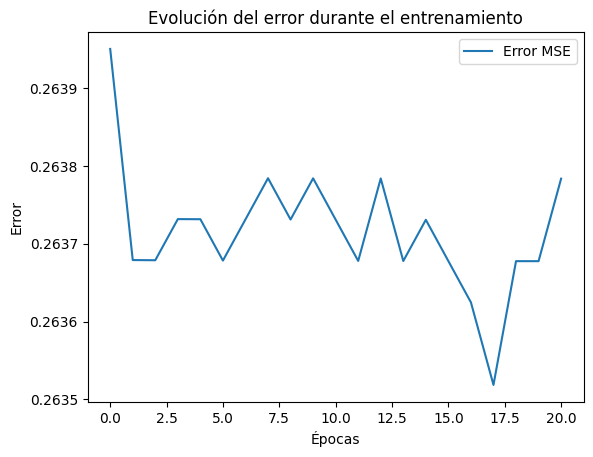

In [9]:
clasificador_mlp.plot_error()

In [10]:
ejemplos_nuevos = ["Que se puede esperar de este perro ladrón"]
# Suponer que se cuenta con el objeto vec_tfidf entrenado con el vocabulario del conjunto de entrenamiento
X_ejemplos_tfidf = vec_tfidf.transform(ejemplos_nuevos)
X_ejemplos_tfidf = X_ejemplos_tfidf.toarray()
print(X_ejemplos_tfidf)

y_pred_nuevo = clasificador_mlp.predict(X_ejemplos_tfidf)
y_pred_nuevo = y_pred_nuevo.flatten()
print(le.inverse_transform(y_pred_nuevo))

[[0. 0. 0. ... 0. 0. 0.]]
['neutral']


In [11]:
import numpy as np


X_test_tfidf = vec_tfidf.transform(X_test)
X_t = X_test_tfidf.toarray()
Y_t = Y_test[:, np.newaxis] # Agregar una dimensión adicional para representar 1 ejemplo de entrenamiento por fila

y_pred_test = clasificador_mlp.predict(X_t)
print(y_pred_test)

[[1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]


In [12]:
print("textos: ", X_test[:5])
print("clase esperada: ",Y_test[:5])
print("clase predicha: ", y_pred_test[:5])

textos:  ['ocupo sacr dinero para mi celular:C yaaaaaaaa'
 'RT @juancani: cambio por iPhone y pago diferencia ... http://t.co/b37QqIly'
 'Me caga que me suspendan mi celular por exceso de limite de crédito si me paso es muy mi pedo! #TeOdioTelcel'
 '@DMtta copiala y guarda un shortcut en el iphone desde los settings del teclado'
 'RT @AntoCapurro: No se si dormir o jugar con el celular.. (La mina estaba en clase)']
clase esperada:  [2 1 0 1 1]
clase predicha:  [[1]
 [1]
 [1]
 [1]
 [1]]


In [13]:
print(Y_test[:10])
print(y_pred_test[:10])

[2 1 0 1 1 1 2 2 1 0]
[[1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]]


In [14]:
# llevar a la misma forma la salida de las predicciones
y_pred_test = y_pred_test.flatten()

print(Y_test[:10])
print(y_pred_test[:10])

[2 1 0 1 1 1 2 2 1 0]
[1 1 1 1 1 1 1 1 1 1]


In [15]:
# Obten las primeras N predicciones
pred =  y_pred_test[:5] 
pred_ori = le.inverse_transform(pred)
pred, pred_ori

(array([1, 1, 1, 1, 1]),
 array(['neutral', 'neutral', 'neutral', 'neutral', 'neutral'],
       dtype=object))

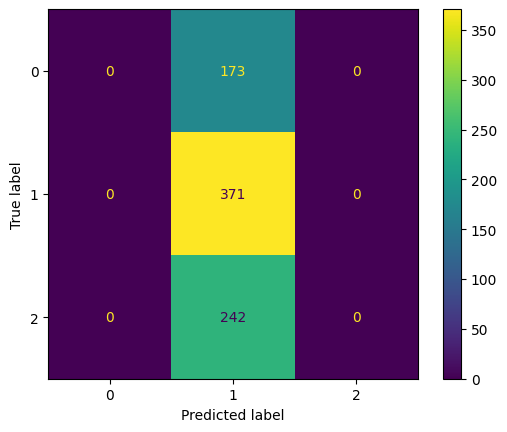

In [16]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(Y_test, y_pred_test)

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
print("P=", precision_score(Y_test, y_pred_test, average='macro'))
print("R=", recall_score(Y_test, y_pred_test, average='macro'))
print("F1=", f1_score(Y_test, y_pred_test, average='macro'))
print("Acc=", accuracy_score(Y_test, y_pred_test))

P= 0.15733672603901613
R= 0.3333333333333333
F1= 0.21377124747911266
Acc= 0.4720101781170484


d:\Apps\envs\RNA\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [18]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(Y_test, y_pred_test))

[[  0 173   0]
 [  0 371   0]
 [  0 242   0]]


In [19]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, y_pred_test, digits=4, zero_division='warn'))

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       173
           1     0.4720    1.0000    0.6413       371
           2     0.0000    0.0000    0.0000       242

    accuracy                         0.4720       786
   macro avg     0.1573    0.3333    0.2138       786
weighted avg     0.2228    0.4720    0.3027       786



d:\Apps\envs\RNA\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Apps\envs\RNA\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Apps\envs\RNA\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
